# Multifractal Analysis

In [1]:
import importlib

# List of libraries to check
libraries = [
    'numpy',
    'matplotlib',
    'scipy',
    'torch',
    'torchdiffeq',
    'torchsummary',
    'minepy',
    'pyrqa',
    'pyts',
    'MFDFA',
    'pyinform',
    'graphviz',
    'fa2',
    'networkx'
]

for lib in libraries:
    try:
        module = importlib.import_module(lib)
        version = getattr(module, '__version__', 'Unknown version')
        print(f'{lib}: {version}')
    except ImportError:
        print(f'{lib} is not installed.')

numpy: 1.24.3
matplotlib: 3.7.0
scipy: 1.10.1
torch: 2.0.1+cu117
torchdiffeq: 0.2.3
torchsummary: Unknown version
minepy: b'1.2.6'
pyrqa: Unknown version
pyts: 0.12.0
MFDFA: 0.4.3
pyinform: Unknown version
graphviz: 0.20.1
fa2 is not installed.
networkx: 3.0


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>The examination of multifractal properties of EEG data is essential for understanding the underlying complex dynamics. A popular technique for such analysis is Multifractal Detrended Fluctuation Analysis (MFDFA), which is employed here to delineate the multifractal spectrum of EEG data across various channels. The MFDFA technique facilitates the discernment of self-affine properties of signals across multiple scales.</p>
        <h2>Mathematical Foundations</h2>
        <p>MFDFA is grounded on the calculation of fluctuation functions \( F_q(s) \) for different segments of the time series, followed by a scaling analysis. The fluctuation function is given by:</p>
        \[ F_q(s) = \left[ \frac{1}{2N_s} \sum_{v=1}^{2N_s} F^2(v, s) \right]^{1/q} \]
        <p>where \( s \) is the scale, \( N_s \) is the number of segments, \( v \) is the segment index, and \( F(v, s) \) is the fluctuation in segment \( v \) at scale \( s \). The exponent \( q \) allows us to investigate multifractal properties; for \( q=2 \), this reduces to traditional DFA.</p>
        <p>The scaling behavior is then analyzed by fitting a straight line to the log-log plot of \( F_q(s) \) versus \( s \), which reveals the Hurst exponents \( h(q) \), and consequently, the multifractal spectrum \( f(\alpha) \).</p>
        <h2>MFDFA Process</h2>
        <p>The MFDFA begins with the integration of the time series, followed by dividing the integrated series into segments. A local trend is removed from each segment, and the variance of the residual series is computed. This process is performed across multiple scales to obtain the fluctuation function \( F_q(s) \).</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Implementation Synopsis</h2>
        <p>The EEG data is loaded, followed by the configuration of the scale and \( q \) values for the MFDFA. The scale range and \( q \) values are chosen to cover a broad range, encapsulating various fractal properties.</p>
        <p>A loop iterates through each EEG channel, invoking the MFDFA function to calculate the scale and fluctuation functions. These results are stored for further analysis, and a visual representation is generated for each channel, showcasing the raw EEG data alongside its multifractal spectrum.</p>
        <h2>Data Visualization</h2>
        <p>Each channel's data is plotted in time domain, and its corresponding multifractal spectrum is exhibited in a log-log plot. This juxtaposition elucidates the multifractal nature of the EEG data and its manifestation across different channels.</p>
        <h2>Conclusion</h2>
        <p>The exercise unveils the multifractal characteristics of EEG data, furnishing crucial insights into the underlying dynamics. The visual representation augments comprehension of the multifractal behavior inherent in EEG data across different channels, forming a foundation for further explorations into the complex dynamics of brain signals.</p>
    </div>
</div>


# MFDFA

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_idx = int(start_time * sampling_rate)
end_idx   = int(end_time * sampling_rate)

eeg_channels = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# MFDFA parameters
lag = np.logspace(0.7, 4, 30).astype(int)
lag = np.unique(lag)
q_vals = np.linspace(-5, 5, 41)   # includes q=0
poly_order = 1                    # DFA-1 (linear detrending)

# -------------------------------------------------------
# LOAD EEG SEGMENT
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

# Handle either (time, channels) or (channels, time)
if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

if EEG_data.shape[1] == len(eeg_channels):
    # shape = (time, channels)
    EEG_segment = EEG_data[start_idx:end_idx, :]
elif EEG_data.shape[0] == len(eeg_channels):
    # shape = (channels, time)
    EEG_segment = EEG_data[:, start_idx:end_idx].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

num_timepoints, num_channels = EEG_segment.shape
print(f"Loaded EEG segment: {num_timepoints} samples x {num_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# Keep only valid scales
lag = lag[(lag > poly_order + 2) & (lag < num_timepoints // 4)]
print("Using scales:", lag)

# -------------------------------------------------------
# MANUAL MFDFA
# -------------------------------------------------------
def mfdfa_manual(x, scales, q_vals, order=1):
    """
    Manual Multifractal DFA (MFDFA).

    Parameters
    ----------
    x : 1D array
        Signal.
    scales : 1D array
        Window sizes.
    q_vals : 1D array
        q values for multifractal fluctuation functions.
    order : int
        Polynomial detrending order (1 = DFA-1).

    Returns
    -------
    scales_out : 1D array
    Fq : 2D array of shape (n_scales, n_q)
        Fluctuation function for each scale and q.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)

    # Step 1: build profile
    profile = np.cumsum(x - np.mean(x))

    Fq = np.full((len(scales), len(q_vals)), np.nan, dtype=float)

    for si, s in enumerate(scales):
        s = int(s)
        Ns = N // s
        if Ns < 2:
            continue

        F2_segments = []

        # Forward segments
        for v in range(Ns):
            start = v * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        # Backward segments
        for v in range(Ns):
            start = N - (v + 1) * s
            stop = start + s
            seg = profile[start:stop]
            t = np.arange(s)

            coeffs = np.polyfit(t, seg, order)
            trend = np.polyval(coeffs, t)
            F2 = np.mean((seg - trend) ** 2)
            F2_segments.append(F2)

        F2_segments = np.asarray(F2_segments, dtype=float)
        F2_segments = np.maximum(F2_segments, 1e-12)

        for qi, q in enumerate(q_vals):
            if np.isclose(q, 0.0):
                # q -> 0 limit
                Fq[si, qi] = np.exp(0.5 * np.mean(np.log(F2_segments)))
            else:
                Fq[si, qi] = (np.mean(F2_segments ** (q / 2.0))) ** (1.0 / q)

    return scales, Fq

# -------------------------------------------------------
# OPTIONAL: generalized Hurst exponents h(q)
# -------------------------------------------------------
def estimate_hq(scales, Fq):
    """
    Fit log Fq(s) vs log s for each q.
    Returns h(q) for each q.
    """
    log_s = np.log(scales)
    hq = np.full(Fq.shape[1], np.nan, dtype=float)

    for qi in range(Fq.shape[1]):
        y = Fq[:, qi]
        mask = np.isfinite(y) & (y > 0)
        if np.sum(mask) >= 5:
            coef = np.polyfit(log_s[mask], np.log(y[mask]), 1)
            hq[qi] = coef[0]

    return hq

# -------------------------------------------------------
# RUN FOR EACH CHANNEL
# -------------------------------------------------------
mfdfa_results = []

for ch in range(num_channels):
    x = EEG_segment[:, ch].astype(float)

    scales_out, fluct = mfdfa_manual(x, lag, q_vals, order=poly_order)
    hq = estimate_hq(scales_out, fluct)

    mfdfa_results.append({
        "channel": eeg_channels[ch],
        "scales": scales_out,
        "q_vals": q_vals,
        "Fq": fluct,
        "hq": hq
    })

    # ---------------------------------------------------
    # PLOTS
    # ---------------------------------------------------
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(x)
    plt.title(f"Channel {ch+1}: {eeg_channels[ch]}")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")

    plt.subplot(1, 2, 2)
    plt.loglog(scales_out, fluct)   # one curve per q
    plt.title(f"Channel {ch+1}: Manual MFDFA")
    plt.xlabel("Scale")
    plt.ylabel("Fq(s)")

    plt.tight_layout()
    plt.show()

    # Optional h(q) plot
    plt.figure(figsize=(5, 4))
    plt.plot(q_vals, hq, marker='o')
    plt.title(f"Channel {ch+1}: h(q)")
    plt.xlabel("q")
    plt.ylabel("Generalized Hurst exponent")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy'

In [5]:
# Save mfdfa_results to a file
mfdfa_results_dict = {f'channel_{i}': result for i, result in enumerate(mfdfa_results)}

# Save the results to a file
save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/MFDFA/'  
np.save(save_dir + 'MFDFA_results.npy', mfdfa_results_dict)

# Extract and save features

In [11]:
import numpy as np
import os

# 1. Load MFDFA results
mfdfa_results_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA/MFDFA_results.npy'
mfdfa_results_dict = np.load(mfdfa_results_path, allow_pickle=True).item()

# Convert the results into an array for ease of processing
mfdfa_data = [mfdfa_results_dict[key][1] for key in sorted(mfdfa_results_dict.keys())]  # extracting the fluctuation part
mfdfa_data = np.array(mfdfa_data)  # shape (num_channels, q_size, lag_size)

# 2. Extract CNN and RNN features

# CNN Features
window_size = 10  
step_size = window_size // 2  
n_windows = (mfdfa_data.shape[2] - window_size) // step_size + 1
cnn_features = np.zeros((n_windows, mfdfa_data.shape[0], window_size))

for i in range(n_windows):
    start = i * step_size
    end = start + window_size
    cnn_features[i] = mfdfa_data[:, :, start:end].mean(axis=1)  # Taking mean over q to reduce dimension

# RNN Features
rnn_features = mfdfa_data.mean(axis=1).reshape(mfdfa_data.shape[0], mfdfa_data.shape[2], 1)

# 3. Save the features and print their heads and shapes

save_path = "/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA"
np.save(os.path.join(save_path, 'cnn_mfdfa.npy'), cnn_features)
np.save(os.path.join(save_path, 'rnn_mfdfa.npy'), rnn_features)

print(f"CNN Features Shape: {cnn_features.shape}")
print(f"RNN Features Shape: {rnn_features.shape}")

print("CNN Feature Head:")
print(cnn_features[0, :, :5])

print("RNN Feature Head:")
print(rnn_features[:, :5, :])

CNN Features Shape: (9, 32, 10)
RNN Features Shape: (32, 50, 1)
CNN Feature Head:
[[808.78941721 831.00442732 854.7410567  880.12387655 907.28505507]
 [702.95878259 720.23441807 738.61648119 758.18501829 779.01974983]
 [340.18842364 347.04416282 354.25879743 361.85748201 369.8677704 ]
 [347.94740111 355.05768471 362.535901   370.40556346 378.69189862]
 [464.54112682 474.24992283 484.48328065 495.27454899 506.65882269]
 [425.92907677 435.25576806 445.16549063 455.70478323 466.92387353]
 [295.19338221 302.11861158 309.50598242 317.39657168 325.83563606]
 [230.52373467 236.32210387 242.48060533 249.02668904 255.98996496]
 [249.51939669 256.38016509 263.67960321 271.44548593 279.70636752]
 [345.53220487 353.13214059 361.19101425 369.74267459 378.8229611 ]
 [491.41899525 501.49106744 512.10885031 523.3087109  535.12952201]
 [292.33557652 298.98846364 306.01958873 313.45573303 321.32578637]
 [747.1362778  767.99189053 790.12370047 813.60498171 838.51150602]
 [205.70463205 211.25815164 217.19

# Hurst Exponents

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; flex-wrap: nowrap; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="flex: 1; margin-right: 10px;">
        <h2>Introduction</h2>
        <p>This segment of the code delves into the computation of the Hurst exponent for each channel of the EEG data. The Hurst exponent, denoted as \( H \), is a statistical measure used to categorize the nature of a time series. A value of \( H = 0.5 \) signifies a random process, \( H < 0.5 \) denotes an anti-persistent process, and \( H > 0.5 \) implies a persistent process. The calculation employs the results from the Multifractal Detrended Fluctuation Analysis (MFDFA) performed earlier, specifically using the scale and fluctuation parameters.</p>
        <h2>Mathematical Foundations</h2>
        <p>The Hurst exponent is calculated by fitting a line to the log-log plot of the fluctuation function \( F(s) \) versus the scale \( s \) obtained from MFDFA. The slope of the line in this log-log space gives the Hurst exponent \( H \), mathematically expressed as:</p>
        \[ H = \frac{\log(F(s))}{\log(s)} \]
        <p>The analysis is narrowed down to a specific range of scales to ensure a robust estimation of \( H \).</p>
        <h2>Hurst Exponent Calculation</h2>
        <p>The code iterates through each EEG channel, extracts the scale and fluctuation parameters from the MFDFA results, and computes the mean fluctuation over all time scales for each channel. A line is then fitted in the log-log space of the mean fluctuation versus scale, and the slope of this line yields the Hurst exponent for that particular channel.</p>
    </div>
    <!-- Column 2 -->
    <div style="flex: 1; margin-left: 10px;">
        <h2>Implementation Synopsis</h2>
        <p>The procedure begins by initializing an array to store the Hurst exponent for each channel. It then validates the consistency between the number of channels and the MFDFA results. Upon validation, it iterates through each channel, extracts the pertinent scale and fluctuation parameters, and calculates the mean fluctuation. A snippet of the scale and mean fluctuation values are printed for verification.</p>
        <p>Subsequently, a line is fitted to the log-log plot of the mean fluctuation versus scale within a specified range of scales, and the slope of this line, representing the Hurst exponent, is stored. This process is reiterated for each channel, amassing the Hurst exponents for all channels.</p>
        <h2>Data Preservation</h2>
        <p>The array of Hurst exponents is saved to a specified file for future reference or analysis. This preservation is crucial for building a comprehensive understanding of the EEG data's statistical properties and for facilitating subsequent analyses.</p>
        <h2>Conclusion</h2>
        <p>The script efficiently computes and preserves the Hurst exponents for each EEG channel, enriching the analytical resources for understanding the EEG data's temporal dynamics. The Hurst exponent, being a pivotal statistical measure, provides invaluable insight into the inherent nature of the EEG data, aiding in deciphering the complex dynamics manifest in neurophysiological signals.</p>
    </div>
</div>


In [115]:
# Initialize an array to store the Hurst exponent for each channel
num_channels = eeg_df_values.shape[1]
hurst_exponents = np.zeros(num_channels)

# Check if mfdfa_results has data for each channel
if len(mfdfa_results) != num_channels:
    print("Error: MFDFA results do not have data for each channel.")
else:
    # Loop over each channel
    for ch in range(num_channels):
        # Extract the scale and fluctuation parameters for the current channel
        scale, fluct = mfdfa_results[ch]

        # Calculate the mean fluctuation over all time scales
        mean_fluct = np.mean(fluct, axis=0)

        # Print the head (first 10 elements) of scale and mean fluctuation values for the current channel
        print(f"Channel {ch+1} - Scale:", scale[:10])
        print(f"Channel {ch+1} - Mean Fluctuation:", mean_fluct[:10])

        # Fit a line in log-log space to get the Hurst exponent
        H_hat = np.polyfit(np.log(scale)[4:20], np.log(mean_fluct)[4:20], 1)[0]

        # Store the Hurst exponent for the current channel
        hurst_exponents[ch] = H_hat.item()  # Extract the scalar value

    # Specify the file path for saving the Hurst exponents
    file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/HurstExponents/hurst_exponents.npy'

    # Save the Hurst exponents to the file
    np.save(file_path, hurst_exponents)

    # Print the head (first 10 elements) of the Hurst exponents array
    print("Hurst exponents:", hurst_exponents)

    print("Hurst exponents saved to:", file_path)

Channel 1 - Scale: [ 5  6  8 10 14 18 24 31 40 52]
Channel 1 - Mean Fluctuation: [ 808.78941721  831.00442732  854.7410567   880.12387655  907.28505507
  936.36302415  967.50039245 1000.84106592 1036.52671978 1074.6930805 ]
Channel 2 - Scale: [ 5  6  8 10 14 18 24 31 40 52]
Channel 2 - Mean Fluctuation: [702.95878259 720.23441807 738.61648119 758.18501829 779.01974983
 801.19698379 824.78610711 849.84637455 876.42514008 904.55888951]
Channel 3 - Scale: [ 5  6  8 10 14 18 24 31 40 52]
Channel 3 - Mean Fluctuation: [747.1362778  767.99189053 790.12370047 813.60498171 838.51150602
 864.9218368  892.91779162 922.58511433 954.01441952 987.30251307]
Channel 4 - Scale: [ 5  6  8 10 14 18 24 31 40 52]
Channel 4 - Mean Fluctuation: [486.36037792 496.773076   507.72036538 519.23666113 531.35930219
 544.12894623 557.59006258 571.79156228 586.78762672 602.63883684]
Channel 5 - Scale: [ 5  6  8 10 14 18 24 31 40 52]
Channel 5 - Mean Fluctuation: [414.07400572 422.69823946 431.79658924 441.40679474 

# Montage Setup for EEG Channels

In [104]:
scalp_positions_1010 = {
    'Fp1': (-0.9511, -0.3090),
    'Fpz': (-1.0000, 0.0000),
    'Fp2': (-0.9511, 0.3090),
    'F7': (-0.5878, -0.8090),
    'F3': (-0.8090, -0.5878),
    'Fz': (-0.8090, 0.0000),
    'F4': (-0.8090, 0.5878),
    'F8': (-0.5878, 0.8090),
    'FC5': (-0.4045, -0.8090),
    'FC1': (-0.6545, -0.3090),
    'FC2': (-0.6545, 0.3090),
    'FC6': (-0.4045, 0.8090),
    'M1': (0.1545, -1.0000),
    'T7': (-0.0000, -1.0000),
    'C3': (-0.3090, -0.9511),
    'Cz': (0.0000, -0.8090),
    'C4': (-0.3090, -0.9511),
    'T8': (0.0000, 1.0000),
    'M2': (0.1545, 1.0000),
    'CP5': (0.4045, -0.8090),
    'CP1': (0.6545, -0.3090),
    'CP2': (0.6545, 0.3090),
    'CP6': (0.4045, 0.8090),
    'P7': (0.5878, -0.8090),
    'P3': (0.8090, -0.5878),
    'Pz': (0.8090, 0.0000),
    'P4': (0.8090, 0.5878),
    'P8': (0.5878, 0.8090),
    'POz': (0.9511, 0.0000),
    'O1': (1.0000, -0.3090),
    'Oz': (1.0000, 0.0000),
    'O2': (1.0000, 0.3090)
}

# Create an MNE info object with channel names and sampling rate
info = mne.create_info(ch_names=list(channel_names), sfreq=sampling_rate, ch_types='eeg')

# Create the montage
montage = mne.channels.make_dig_montage(ch_pos=dict(zip(channel_names, scalp_positions)), coord_frame='head')

# Set the montage to the Info object
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FC5, FC1, FC2, FC6, M1, T7, ...
 chs: 32 EEG
 custom_ref_applied: False
 dig: 35 items (3 Cardinal, 32 EEG)
 highpass: 0.0 Hz
 lowpass: 500.0 Hz
 meas_date: unspecified
 nchan: 32
 projs: []
 sfreq: 1000.0 Hz
>

# Visualizing Mean Hurst Exponent Topographical Map

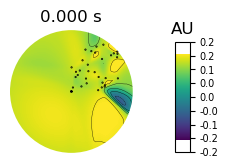

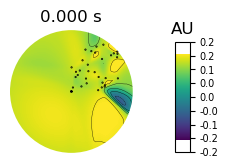

In [129]:
import numpy as np
import mne

# Replace the following variables with your actual data
num_channels = 32  # Number of EEG channels
mean_hurst_exponent = hurst_exponents  # Array with mean Hurst exponent value for each channel
grid_size = 10

# Generate random scalp positions with a small random offset to avoid overlapping
offset = 0.1
scalp_positions = np.random.uniform(0, grid_size - offset, size=(num_channels, 2))
scalp_positions += np.random.uniform(0, offset, size=(num_channels, 2))
scalp_positions_3d = [(*pos, 0) for pos in scalp_positions]

# Step 1: Organize mean Hurst exponent values into a 2D grid corresponding to scalp positions
# Initialize the mean_hurst_exponent_map with NaN values to avoid index out of bounds error
mean_hurst_exponent_map = np.full((grid_size, grid_size), np.nan)

for i in range(num_channels):
    x, y = scalp_positions[i]
    mean_hurst_exponent_map[int(x), int(y)] = mean_hurst_exponent[i]

# Step 2: Plot the topographical map using MNE-Python
# Create an MNE info object with channel names and montage information
channel_names = [f'EEG {i+1}' for i in range(num_channels)]
sampling_rate = 1000  # Replace with your actual sampling rate
info = mne.create_info(ch_names=channel_names, sfreq=sampling_rate, ch_types='eeg')

# Create a digitization object and add electrode locations to it
dig = mne.channels.make_dig_montage(ch_pos=dict(zip(channel_names, scalp_positions_3d)), coord_frame='head')

# Add the digitization to the info object
info.set_montage(dig)

# Create the EvokedArray with your mean Hurst exponent data
data = mean_hurst_exponent[:, np.newaxis]
evoked = mne.EvokedArray(data, info)

# Plot the topographical map of mean Hurst exponent values
evoked.plot_topomap(times=0, scalings=1.0, cmap='viridis')

# Consider performing statistical tests (e.g., ANOVA, t-test) to assess group differences or condition-related variations in the mean Hurst exponent values

# Load saved MFDFA results and plot them

In [16]:
# Load the MFDFA results from the file
save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA/'  # the directory path where you saved the file
mfdfa_results = np.load(save_dir + 'MFDFA_results.npy', allow_pickle=True)

In [17]:
# Check if mfdfa_results has data for each channel
num_channels = mfdfa_results.shape[0]
if num_channels == 0:
    print("Error: MFDFA results do not have data for any channel.")
else:
    # Initialize an array to store the Hurst exponent for each channel
    hurst_exponents = np.zeros(num_channels)

    # Loop over each channel
    for ch in range(num_channels):
        # Extract the scale and fluctuation parameters for the current channel
        scale, fluct, _, _ = saved_mfdfa_results[ch]

        # Fit a line in log-log space to get the Hurst exponent
        H_hat = np.polyfit(np.log(scale)[4:20], np.log(fluct)[4:20], 1)[0]

        # Store the Hurst exponent for the current channel
        hurst_exponents[ch] = H_hat

    # Visualize the results
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, num_channels + 1), hurst_exponents)
    plt.xlabel('Channel')
    plt.ylabel('Hurst Exponent')
    plt.title('Hurst Exponent for Each EEG Channel')
    plt.show()

IndexError: tuple index out of range

# MFDFA Feature Extraction and Data Formatting

In [19]:
import numpy as np
import os

# Load the MFDFA results from the file
save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA/'  
mfdfa_results = np.load(save_dir + 'MFDFA_results.npy', allow_pickle=True)


# Define the number of timesteps in each input sequence
timesteps = 100

# Create continuous data by concatenating all scale and fluctuation arrays
continuous_scale = np.concatenate([scale for scale, _ in mfdfa_results])
continuous_fluct = np.concatenate([fluct for _, fluct in mfdfa_results])

# Initialize X data
cnn_X_data = []
rnn_X_data = []

# Create overlapping sequences
for i in range(len(continuous_scale) - timesteps):
    scale_seq = continuous_scale[i : i + timesteps]
    fluct_seq = continuous_fluct[i : i + timesteps]
    seq = np.column_stack([scale_seq, fluct_seq])
    
    cnn_X_data.append(seq.flatten())  # Flatten sequence for CNN
    rnn_X_data.append(seq)  # Keep sequence shape for RNN

# Convert lists to numpy arrays
cnn_X_data = np.array(cnn_X_data)
rnn_X_data = np.array(rnn_X_data)

print("Shape of cnn_X_data:", cnn_X_data.shape)
print("Shape of rnn_X_data:", rnn_X_data.shape)

save_path = "/home/vincent/AAA_projects/MVCS/Neuroscience/Analysis/MFDFA"
np.save(os.path.join(save_path, 'cnn_mfdfa_concatenated.npy'), cnn_X_data)
np.save(os.path.join(save_path, 'rnn_mfdfa_concatenated.npy'), rnn_X_data)


TypeError: iteration over a 0-d array

In [24]:
print(mfdfa_results)


{'channel_0': (array([    5,     6,     8,    10,    14,    18,    24,    31,    40,
          52,    68,    89,   116,   151,   196,   255,   331,   431,
         560,   727,   945,  1229,  1597,  2076,  2697,  3506,  4556,
        5921,  7694, 10000]), array([[3.17812754e-01, 3.54225702e-01, 3.97791564e-01, ...,
        1.55199608e+02, 1.67307625e+02, 1.79692663e+02],
       [1.06771347e+00, 1.15658587e+00, 1.25650014e+00, ...,
        1.88711853e+02, 2.02926240e+02, 2.17466373e+02],
       [2.91624019e+00, 3.06278577e+00, 3.21751270e+00, ...,
        2.61666838e+02, 2.81624459e+02, 3.02396051e+02],
       ...,
       [2.76022917e+03, 2.87026143e+03, 2.99107366e+03, ...,
        5.74617372e+05, 6.00112829e+05, 6.24710145e+05],
       [5.00978504e+03, 5.16203350e+03, 5.32575195e+03, ...,
        7.54650370e+05, 7.85482412e+05, 8.15147759e+05],
       [8.75979602e+03, 8.94817355e+03, 9.14550353e+03, ...,
        9.71676625e+05, 1.00678134e+06, 1.04030819e+06]])), 'channel_1': (array([ 

In [31]:
# Print shape and first elements of CNN data
print("Shape of cnn_X_data:", cnn_X_data.shape)
print("First element of cnn_X_data:\n", cnn_X_data[0])

# Print shape and first elements of RNN data
print("Shape of rnn_X_data:", rnn_X_data.shape)
print("First element of rnn_X_data:\n", rnn_X_data[0])

Shape of cnn_X_data: (860, 5100)
First element of cnn_X_data:
 [0.00000000e+00 0.00000000e+00 3.50020883e-08 ... 1.02874780e-02
 1.06212100e-02 1.09375542e-02]
Shape of rnn_X_data: (860, 100, 51)
First element of rnn_X_data:
 [[0.00000000e+00 0.00000000e+00 3.50020883e-08 ... 1.48880730e-04
  1.60519608e-04 1.72424775e-04]
 [1.00050025e-04 7.20844984e-07 8.06273925e-07 ... 1.81094506e-04
  1.94758141e-04 2.08734901e-04]
 [3.00150075e-04 2.49774851e-06 2.63861602e-06 ... 2.51222770e-04
  2.70407111e-04 2.90373884e-04]
 ...
 [2.60130065e-03 3.42822519e-06 3.53222373e-06 ... 8.57237580e-03
  8.87304395e-03 9.16003688e-03]
 [3.50175088e-03 4.44041983e-06 4.55638833e-06 ... 1.00475252e-02
  1.03789221e-02 1.06936306e-02]
 [4.70235118e-03 5.62150246e-06 5.74783045e-06 ... 1.02874780e-02
  1.06212100e-02 1.09375542e-02]]


In [10]:
 print("Shape of cnn_X_data:", cnn_X_data.shape)
print(cnn_X_data.head())

Shape of cnn_X_data: (860, 5100)
        0             1             2             3             4  \
0  0.0000  0.000000e+00  3.500209e-08  7.687994e-08  1.273251e-07   
1  0.0001  7.208450e-07  8.062739e-07  9.023169e-07  1.009805e-06   
2  0.0003  2.497749e-06  2.638616e-06  2.787348e-06  2.943969e-06   
3  0.0005  4.023184e-06  4.207777e-06  4.401253e-06  4.603944e-06   
4  0.0009  6.903312e-06  7.153461e-06  7.418168e-06  7.697934e-06   

              5             6             7             8             9  ...  \
0  1.884323e-07  2.627076e-07  3.529606e-07  4.619666e-07  5.917862e-07  ...   
1  1.129261e-06  1.260744e-06  1.403757e-06  1.557257e-06  1.719825e-06  ...   
2  3.108491e-06  3.280934e-06  3.461341e-06  3.649793e-06  3.846420e-06  ...   
3  4.816177e-06  5.038258e-06  5.270445e-06  5.512933e-06  5.765839e-06  ...   
4  7.993139e-06  8.304015e-06  8.630621e-06  8.972824e-06  9.330300e-06  ...   

       5090      5091      5092      5093      5094      5095      5096

# Save MFDFA X data for CNN and RNN as numpy

In [3]:
import pandas as pd
import numpy as np

# Path to the CSV file
csv_file_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/cnn_X_df.csv'

# Load the CSV file into a DataFrame
cnn_X_data = pd.read_csv(csv_file_path)

cnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'
# Save CNN data
np.save(cnn_save_dir + 'cnn_mfdfa.npy', cnn_X_data)

In [16]:
# Define the directory paths where you want to save the data
cnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'
rnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/RNN_data/'

# Save CNN data
np.save(cnn_save_dir + 'cnn_mfdfa_X_df.npy', cnn_X_data)

# Save RNN data
np.save(rnn_save_dir + 'rnn_mfdfa_X_df.npy', rnn_X_data)

In [ ]:
# Define the directory paths where you want to save the data
cnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'

# Save CNN data
np.save(cnn_save_dir + 'cnn_mfdfa_X_df.npy', cnn_X_data

# Load  Hurst exponents as numpy

In [18]:
# Load the saved Hurst exponents from the file
hurst_exponents_npy = np.load('/home/vincent/AAA_projects/MVCS/Neuroscience/HurstExponents/hurst_exponents.npy')

# Load MFDFA RNN X data as numpy

In [22]:
# Load data
rnn_mfdfa_X_df_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/RNN_data/'

# Load RNN data
rnn_mfdfa_X_df_npy = np.load(rnn_mfdfa_X_df_path + 'rnn_mfdfa_X_df.npy')

# Load MFDFA CNN X data as numpy

In [ ]:
# Load data
cnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'

# Load CNN data
rnn_mfdfa_X_df_npy = np.load(rnn_mfdfa_X_df_path + 'cnn_mfdfa_X_df.npy')

# Convert RNN, CNN X data, and Hurst exp data from numpy to df

In [38]:
# Display the shapes
print("Shape of cnn_mfdfa_X_df:", cnn_mfdfa_X_df.npy.shape)
print("Shape of rnn_mfdfa_X_df.npy:", rnn_mfdfa_X_df.npy.shape)

# Convert the 3D CNN data to a DataFrame
cnn_X_df = pd.DataFrame(cnn_mfdfa_X_df)

# Convert the 3D RNN data to a list of DataFrames with generic column labels
rnn_X_df = [pd.DataFrame(time_series) for time_series in rnn_mfdfa_X_df.npy]

# Display the head of the first DataFrame in the list
print("cnn_X_df:")
print(cnn_X_df.head())
print()

# Display the head of the first 5 DataFrames in the list
print("rnn_X_df:")
for i, df in enumerate(rnn_X_df[:5]):
    print(f"DataFrame {i+1}:")
    print(df.head())
    print()

# Assuming hurst_exponents_npy has shape (32,)
# Convert Numpy array to DataFrame
hurst_exponents_df = pd.DataFrame(hurst_exponents_npy)

print("hurst_exponents:")
print(hurst_exponents_df.head())

Shape of cnn_X_data: (860, 5100)
Shape of rnn_X_data: (860, 100, 51)
cnn_X_df:
     0             1             2             3             4     \
0  0.0000  0.000000e+00  3.500209e-08  7.687994e-08  1.273251e-07   
1  0.0001  7.208450e-07  8.062739e-07  9.023169e-07  1.009805e-06   
2  0.0003  2.497749e-06  2.638616e-06  2.787348e-06  2.943969e-06   
3  0.0005  4.023184e-06  4.207777e-06  4.401253e-06  4.603944e-06   
4  0.0009  6.903312e-06  7.153461e-06  7.418168e-06  7.697934e-06   

           5             6             7             8             9     ...  \
0  1.884323e-07  2.627076e-07  3.529606e-07  4.619666e-07  5.917862e-07  ...   
1  1.129261e-06  1.260744e-06  1.403757e-06  1.557257e-06  1.719825e-06  ...   
2  3.108491e-06  3.280934e-06  3.461341e-06  3.649793e-06  3.846420e-06  ...   
3  4.816177e-06  5.038258e-06  5.270445e-06  5.512933e-06  5.765839e-06  ...   
4  7.993139e-06  8.304015e-06  8.630621e-06  8.972824e-06  9.330300e-06  ...   

       5090      5091    

# Load MFDFA CNN X data as numpy

In [28]:
# Define file paths
cnn_save_dir = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'
cnn_mfdfa_X_data_path = cnn_save_dir + 'cnn_mfdfa_X_data.npy'

# Load the data as numpy arrays
cnn_mfdfa_X_data = np.load(cnn_mfdfa_X_data_path)
cnn_mfdfa_Y_data = np.load(cnn_mfdfa_Y_data_path)

# Now you have the data as numpy arrays
print("cnn_mfdfa_X_data:")
print(cnn_mfdfa_X_data)

print("cnn_mfdfa_Y_data:")
print(cnn_mfdfa_Y_data)

cnn_mfdfa_X_data:
[[[0.00000000e+00 0.00000000e+00 3.50020883e-08 ... 1.48880730e-04
   1.60519608e-04 1.72424775e-04]
  [1.00050025e-04 7.20844984e-07 8.06273925e-07 ... 1.81094506e-04
   1.94758141e-04 2.08734901e-04]
  [3.00150075e-04 2.49774851e-06 2.63861602e-06 ... 2.51222770e-04
   2.70407111e-04 2.90373884e-04]
  ...
  [5.91895948e-01 2.65297556e-03 2.75874450e-03 ... 5.52352885e-01
   5.76860492e-01 6.00504758e-01]
  [7.69284642e-01 4.81536991e-03 4.96171933e-03 ... 7.25410306e-01
   7.55047727e-01 7.83563658e-01]
  [1.00000000e+00 8.42008260e-03 8.60116123e-03 ... 9.34027641e-01
   9.67772183e-01 1.00000000e+00]]

 [[0.00000000e+00 0.00000000e+00 3.69707482e-08 ... 1.61467172e-04
   1.68815702e-04 1.76239232e-04]
  [1.00050025e-04 5.31267875e-07 6.21884324e-07 ... 2.29331598e-04
   2.38569405e-04 2.47610948e-04]
  [3.00150075e-04 2.33442819e-06 2.45704109e-06 ... 4.04356107e-04
   4.19903355e-04 4.34902090e-04]
  ...
  [5.91895948e-01 2.75757024e-03 2.89119975e-03 ... 5.03398

# Save MFDFA CNN X data as df

In [40]:
# Define the save directory
cnn_save_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/CNN_data/'

# Save the CNN X data
cnn_X_df.to_csv(cnn_save_path + 'cnn_X_df.csv', index=False)

# Save MFDFA RNN X data and Hurst exp as DF

In [47]:
# Save rnn_mfdfa_X_df
rnn_data_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/RNN_data/'
for i, df in enumerate(rnn_X_df):
    df.to_csv(f"{rnn_data_path}rnn_X_df_{i}.csv", index=False)

# Save hurst_exponents_df
hurst_exponents_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/HurstExponents/'
hurst_exponents_df.to_csv(f"{hurst_exponents_path}hurst_exponents_df.csv", index=False)

# Make the MFDFA RNN X DF 1 file instead of 860

In [48]:
# Combine the list of DataFrames into a single 3D DataFrame
rnn_X_df_combined = np.stack(rnn_X_data)

# The shape of rnn_X_df_combined should be (860, 100, 51)
print("Shape of rnn_X_df_combined:", rnn_X_df_combined.shape)

# Save the combined 3D DataFrame to a CSV file
rnn_data_path = '/home/vincent/AAA_projects/MVCS/Neuroscience/RNN_data/'
np.save(f"{rnn_data_path}rnn_X_data_combined.npy", rnn_X_df_combined)

Shape of rnn_X_df_combined: (860, 100, 51)
